# An introduction to plotlet

plotlet is a Python library for SVG plots — reproducible, byte-identical, with a standard plotting vocabulary built around the data-frame-first idiom.

This notebook walks through the way plotlet wants you to think about a figure: **bind a data frame to a chart, layer one or more marks on top, compose multi-panel layouts**. We'll use the bundled Palmer Penguins dataset throughout.

In [1]:
import pandas as pd
import plotlet as pt
from plotlet import aes

# pt.load returns a column-oriented dict; wrapping it in a DataFrame is
# optional but gives a nice tabular preview and any pandas operations you want.
penguins = pd.DataFrame(pt.load_dataset("penguins"))
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## The basic pattern

Pass a data frame to `pt.chart(...)` and map its columns with `aes(...)` in the mark calls. A bare kwarg is always a literal — `aes(color="species")` maps the column, `color="red"` sets one color. Mapping a categorical column to `color=` (or `fill=` for filled artists) gives one tab10 color per level. Mark methods return the chart, so they chain.

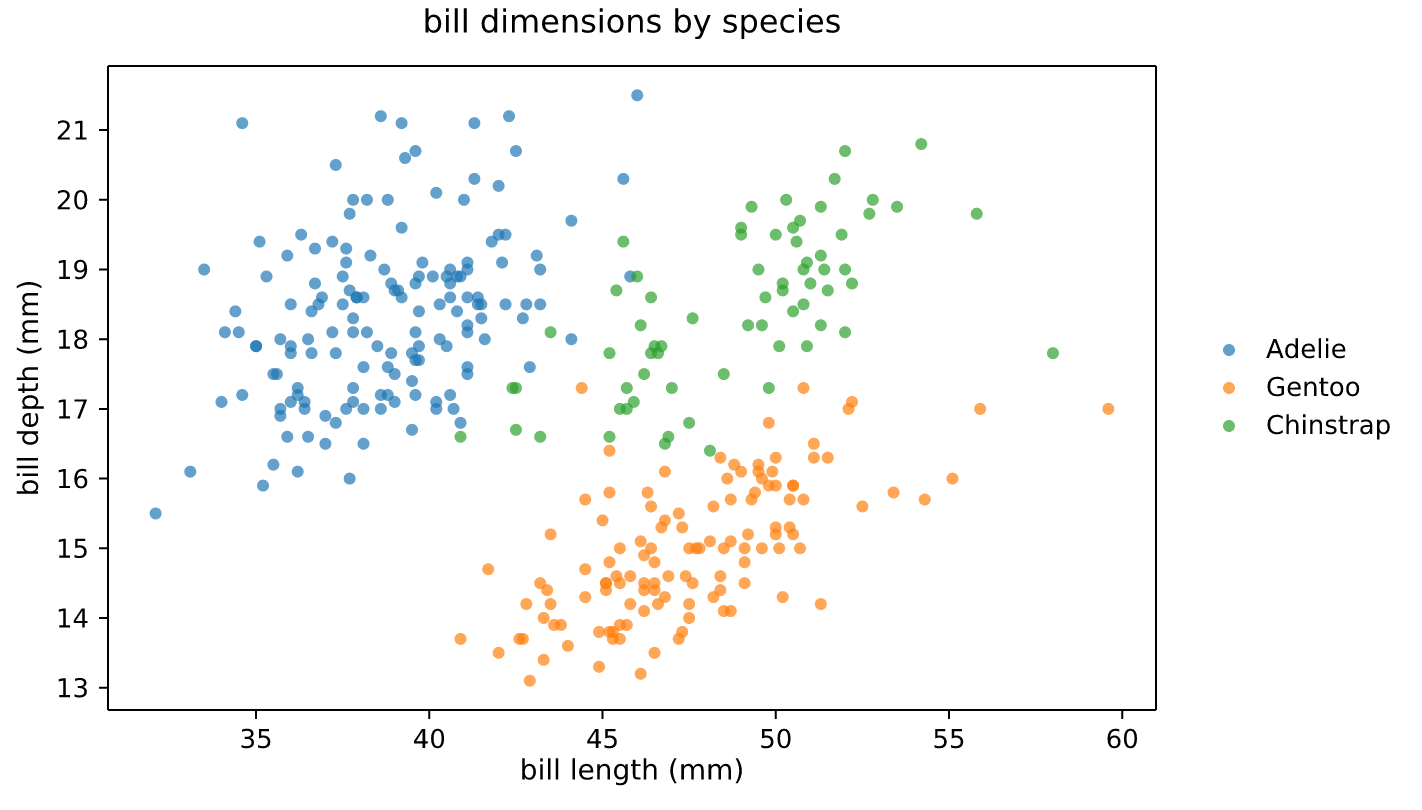

In [2]:
c = pt.chart(penguins,
             title="bill dimensions by species",
             xlabel="bill length (mm)", ylabel="bill depth (mm)",
             legend=True)
c.add_scatter(aes(x="bill_length_mm", y="bill_depth_mm", color="species"),
              size=3, alpha=0.7)
c.legend()
c

## Declare aesthetics once, layer many marks

Bind the data and an `aes(...)` mapping at the chart level and every subsequent mark inherits them. Per-call values always win — only unset slots fall back to the chart-level mapping.

The canonical example is a boxplot with raw points overlaid, both using the same `x` and `y`:

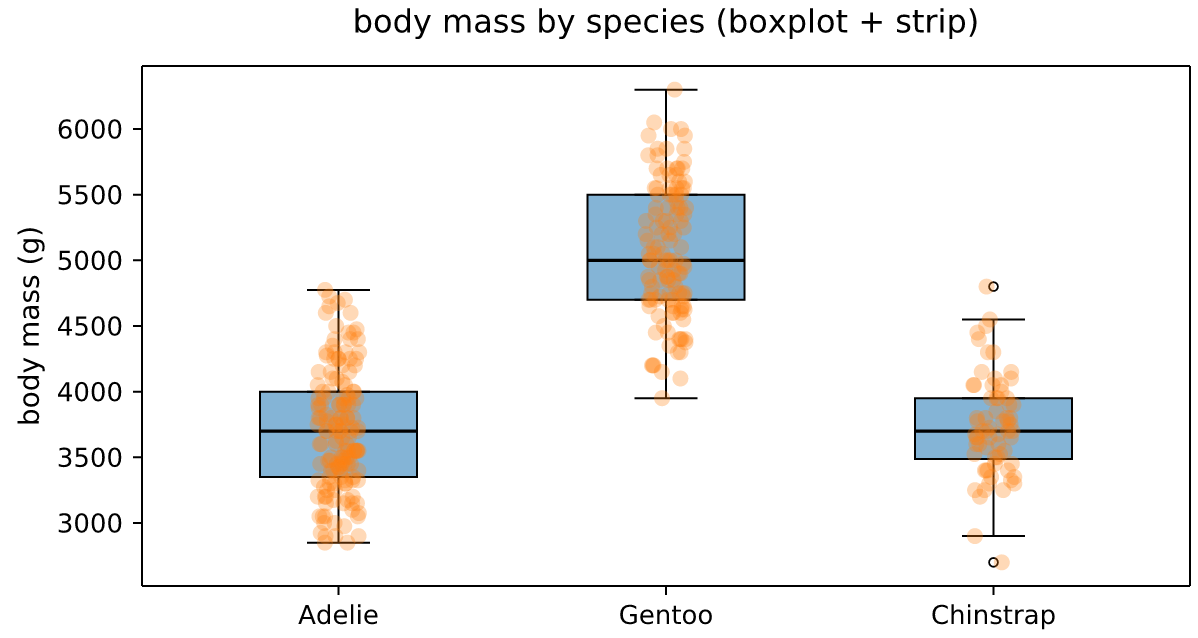

In [3]:
c = pt.chart(penguins, aes(x="species", y="body_mass_g"),
             title="body mass by species (boxplot + strip)",
             ylabel="body mass (g)", data_height=260)
c.add_boxplot()
c.add_strip(size=4, alpha=0.3)
c

Both `add_boxplot()` and `add_strip()` are called with **no arguments** — they inherit `aes(x="species", y="body_mass_g")` from the chart. The same aes apply to every layer; if you want to override one, pass it explicitly:

```python
c.add_scatter(aes(x="other_col"))   # overrides x for just this call
```

## Distributions across groups

`density_1d` (Gaussian KDE) plus `rug` (raw observations as tick marks) makes a clean overlay. Sharing `aes(color=...)` at the chart level keeps the colors consistent across both layers.

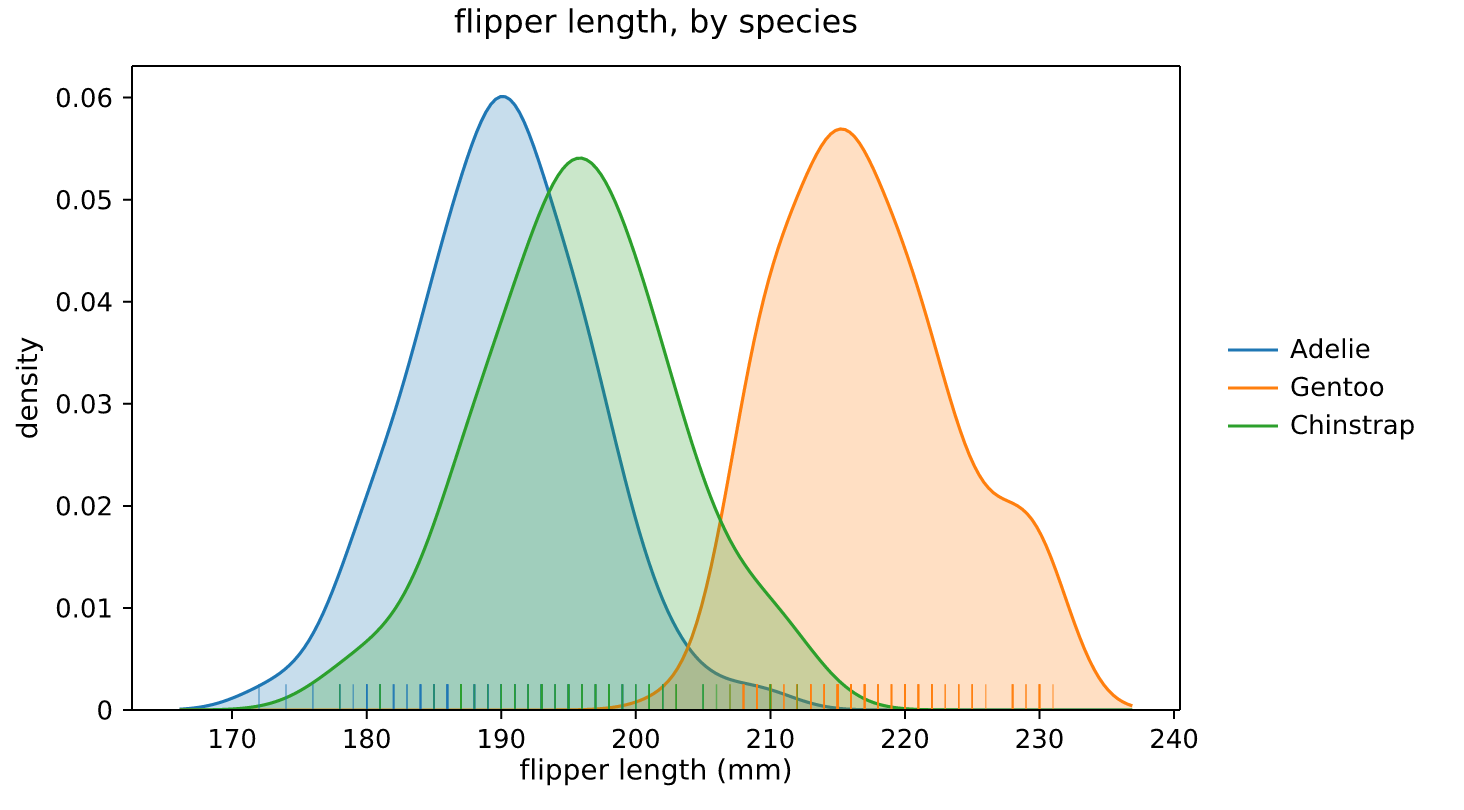

In [4]:
c = pt.chart(penguins, aes(x="flipper_length_mm", color="species"),
             title="flipper length, by species",
             xlabel="flipper length (mm)", ylabel="density",
             legend=True)
c.add_density_1d(fill=True)
c.add_rug()
c.legend()
c

## Multi-panel composition

The `|` operator stacks charts side-by-side; `/` stacks them vertically. They nest — use `(a | b) / c` for an L-shape, or `pt.grid([[a, b], [c, d]])` for arbitrary 2-D layouts. The composed chart owns its children — render the parent.

Three views of body mass in one figure:

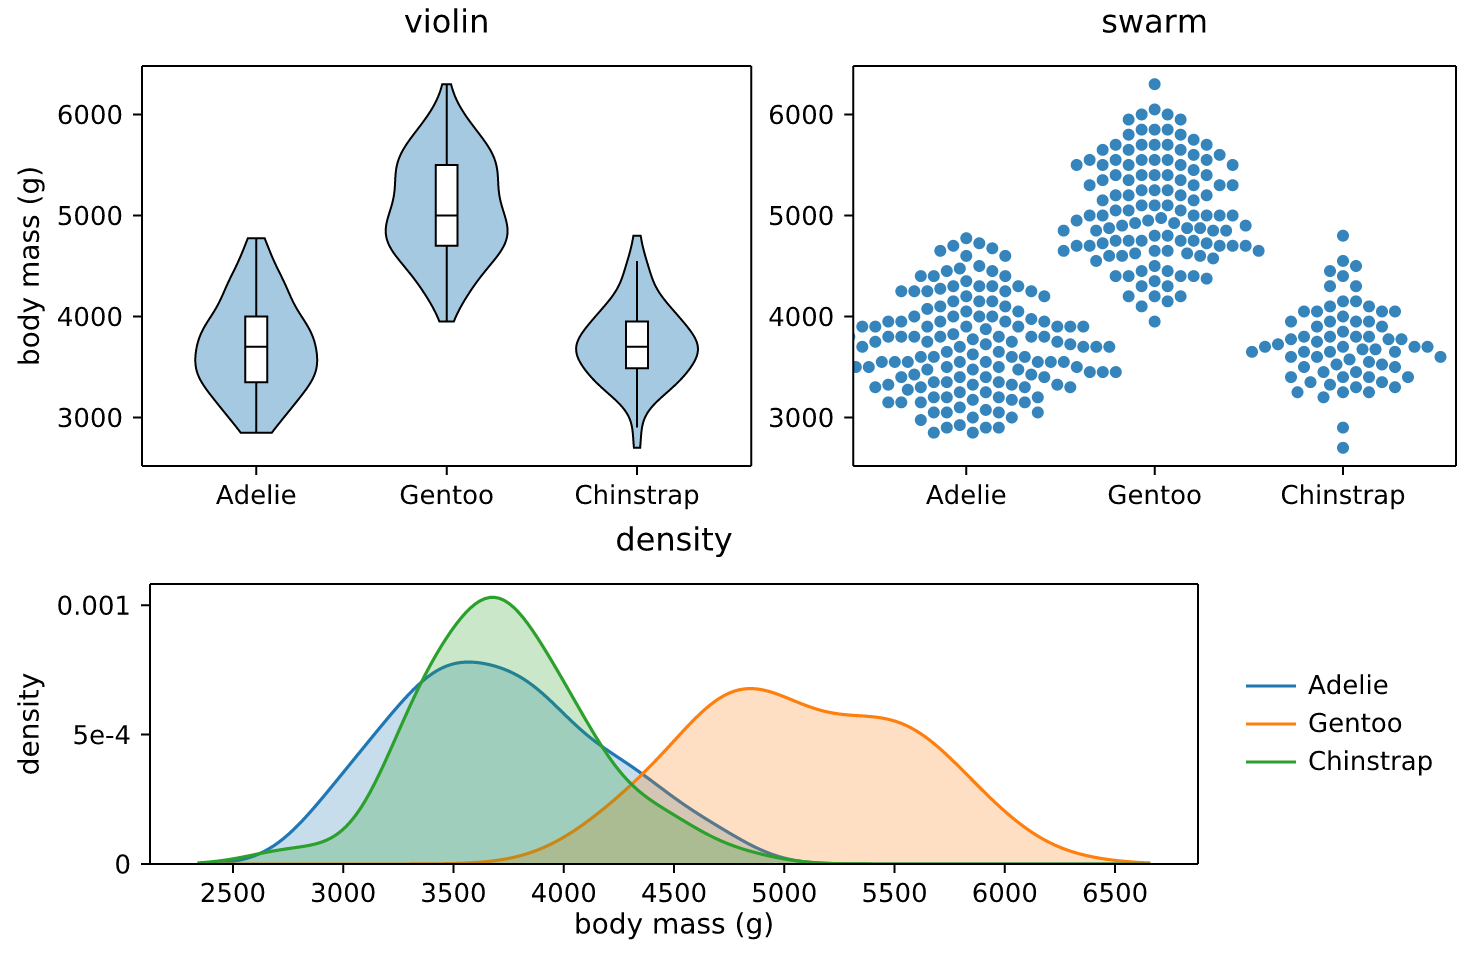

In [5]:
violin = pt.chart(penguins, aes(x="species", y="body_mass_g"),
                  title="violin", ylabel="body mass (g)",
                  data_width=260, data_height=200)
violin.add_violin()

swarm = pt.chart(penguins, aes(x="species", y="body_mass_g"),
                 title="swarm", data_width=260, data_height=200)
swarm.add_swarm(size=3)

density = pt.chart(penguins, aes(x="body_mass_g", color="species"),
                   title="density", xlabel="body mass (g)",
                   ylabel="density", data_height=140, legend=True)
density.add_density_1d(fill=True)
density.legend()

(violin | swarm) / density

## Shared scales

`(a / b).share_x()` collapses the gap between two panels and unions their x-domains so the scale is identical across them. The first leaf is the anchor. The classic use case is a scatter with a marginal distribution below — the x-axis is locked so the marginal density tracks exactly with the data above.

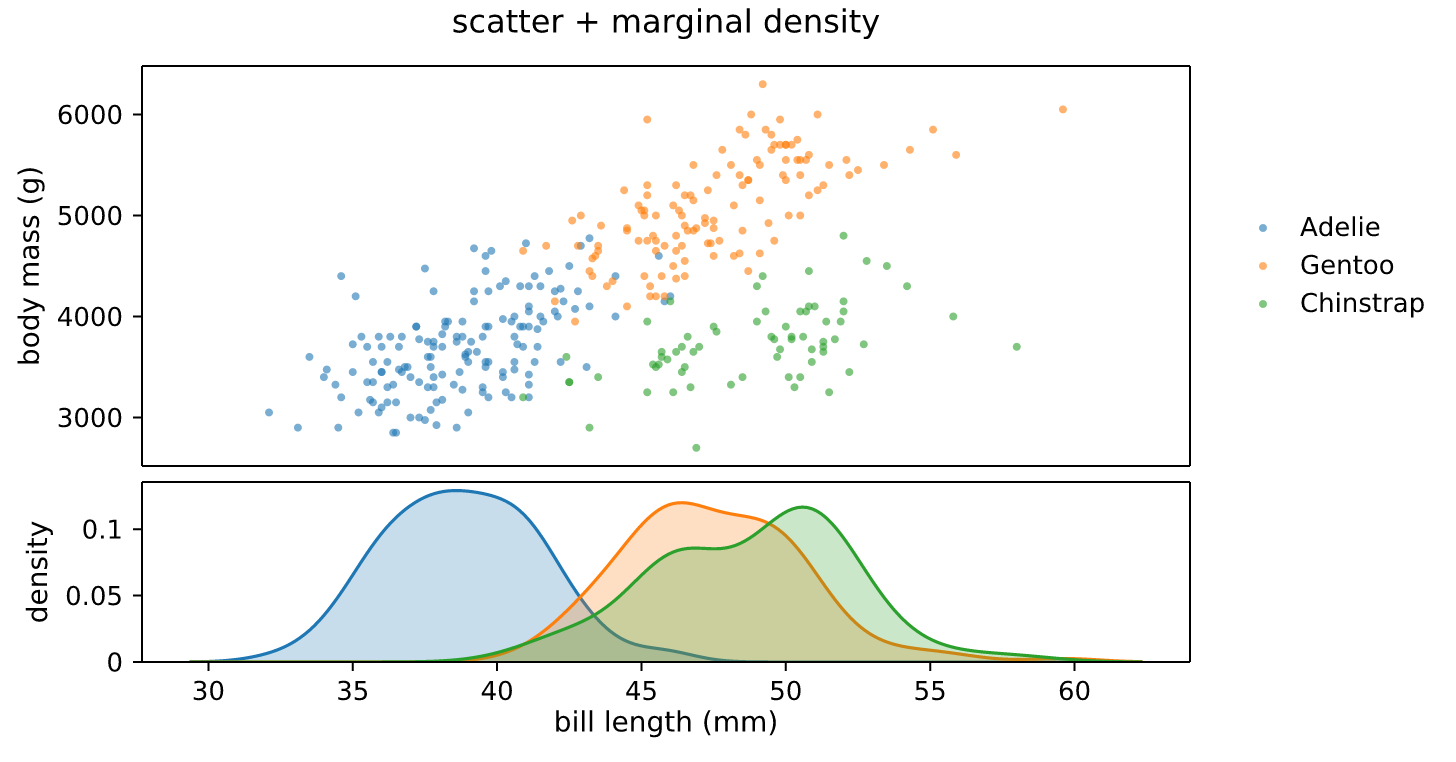

In [6]:
top = pt.chart(penguins, aes(x="bill_length_mm", y="body_mass_g", color="species"),
               title="scatter + marginal density",
               ylabel="body mass (g)", data_height=200, legend=True)
top.add_scatter(size=2, alpha=0.6)
top.legend()

bot = pt.chart(penguins, aes(x="bill_length_mm", color="species"),
               xlabel="bill length (mm)", ylabel="density",
               data_height=90)
bot.add_density_1d(fill=True)

(top / bot).share_x()

## Annotated heatmap

A matrix plus group structure on its rows: heatmap body + dendrogram + a categorical strip carrying the group label. `c.sectors(...)` reserves a gap at every group boundary; `clusters=` makes the dendrogram cluster within each group and order groups by centroid similarity (`parent=True` renders that between-group tree above the per-group trees); the dendrogram's leaf order propagates back to the heatmap via `attach_left`'s implicit `share_y`. Full version with both axes split, two annotation strips, named legend sections: [`cookbook/heatmaps/`](../cookbook/heatmaps/).

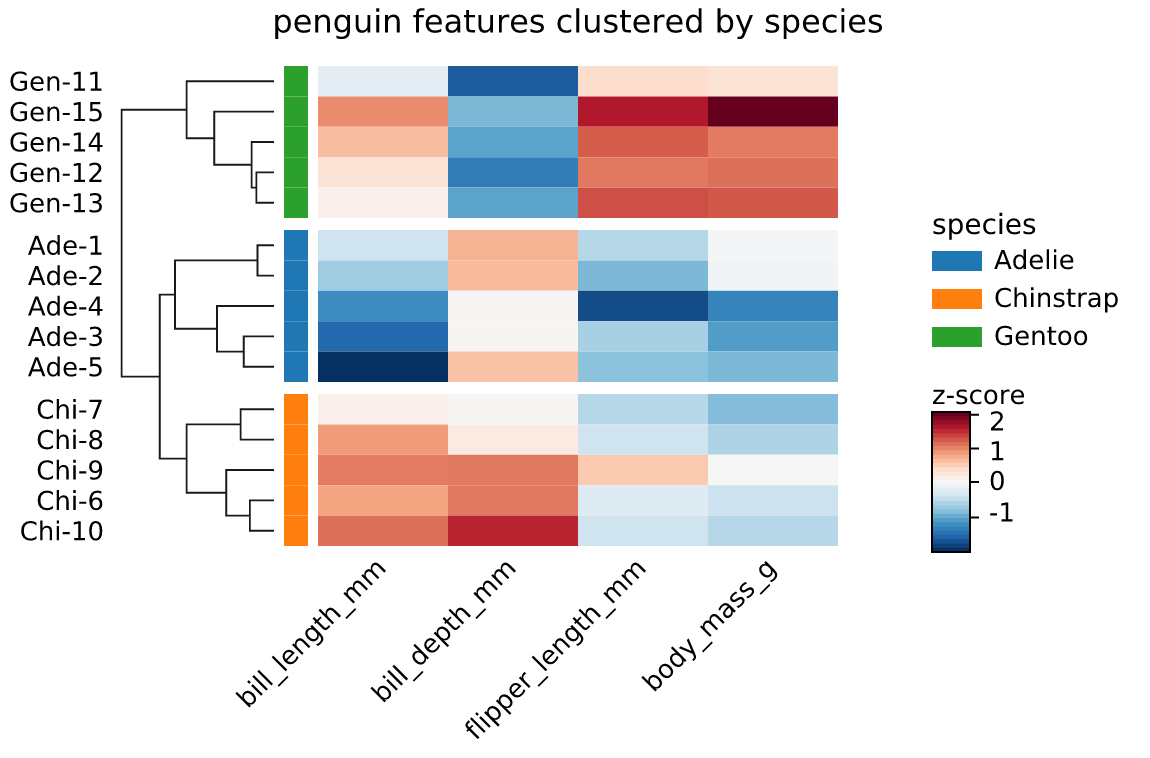

In [7]:
# Five penguins per species; z-score each numeric feature so the diverging
# cmap reads as deviation from the population mean.
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
sample = (penguins.dropna(subset=features)
                  .groupby("species", group_keys=False)
                  .sample(n=5, random_state=0)
                  .sort_values("species"))
z = ((sample[features] - sample[features].mean()) / sample[features].std()).values.tolist()
species = sample["species"].tolist()
labels = [f"{s[:3]}-{i+1}" for i, s in enumerate(species)]

# Heatmap body: sectors reserve gaps at the species boundaries.
# Feature names are long, so rotate the column tick labels.
hm = pt.chart(title="penguin features clustered by species",
              data_width=260, data_height=240)
# Tidy input: one table row per feature (x-axis), one value column per
# sample (track); species clusters become y-sectors (gap = separator).
row_clusters = {}
for lab, sp in zip(labels, species):
    row_clusters.setdefault(sp, []).append(lab)
hm.sectors(row_clusters, axis="y", divider=False, label=False)
hm_df = {"feature": features}
for i, lab in enumerate(labels):
    hm_df[lab] = z[i]
hm.add_heatmap(data=hm_df, mapping=aes(x="feature"), values=labels,
               cmap="RdBu_r", center=0, legend={"label": "z-score"})
hm.xticks(rotation=45)

# Dendrogram: cluster within each species + centroid parent tree.
# Annotation strip: species label as a coloured y-track.
tree  = pt.chart(data_width=80).add_dendrogram(z, clusters=species, labels=labels,
                                               orientation="left", parent=True, method="ward")
strip_df = {"label": labels, "species": species}
strip = pt.chart(data_width=12).add_annotation_strip(
                  strip_df, aes(position="label", value="species"), orientation="y",
                  palette={"Adelie": "C0", "Chinstrap": "C1", "Gentoo": "C2"})

# attach_left auto-shares y; the dendrogram's axis_order drives the
# heatmap's row order, and the strip follows.
hm.attach_left(strip, tree)
pt.grid([[hm, pt.legend(strip, hm, names={strip: "species", hm: None})]])

## A taste of the AI-readable SVG

Every figure emits `data-plotlet-*` attributes describing plot type, axes, scales, ranges, and labels — enough for an AI or downstream tool to understand the figure from one XML parse. Schema: [`docs/AI_ATTRS.md`](../docs/AI_ATTRS.md).

In [8]:
svg = (pt.chart(penguins, aes(x="bill_length_mm", y="bill_depth_mm", color="species"))
         .add_scatter(size=2.5).to_svg())

import re
for m in re.finditer(r'data-plotlet-\w+="[^"]{0,40}"', svg[:1500]):
    print(m.group(0))

data-plotlet-version="0.6.0"
data-plotlet-schema="2"
data-plotlet-kind="layout"
data-plotlet-kind="panel"
data-plotlet-xscale="linear"
data-plotlet-yscale="linear"
data-plotlet-xlim="30.725,60.975"
data-plotlet-ylim="12.68,21.92"
data-plotlet-type="scatter"
data-plotlet-index="0"
data-plotlet-label="Adelie"
data-plotlet-color="#1f77b4"
data-plotlet-n="152"
data-plotlet-marker="o"


## Where to next

- [`docs/API.md`](../docs/API.md) — full method reference, frame options, scales, clustering helpers
- [`docs/PHILOSOPHY.md`](../docs/PHILOSOPHY.md) — what's in core vs extensions and why
- [`docs/SUBPLOTS.md`](../docs/SUBPLOTS.md) — multi-panel composition in depth
- [`docs/EXTENDING.md`](../docs/EXTENDING.md) — write your own plot type (~50–100 lines)
- [`cookbook/heatmaps/`](../cookbook/heatmaps/) — full annotated heatmap: both axes split, parent dendrograms, multiple annotation tracks

The penguins dataset used here is from [Gorman, Williams & Fraser (2014)](https://allisonhorst.github.io/palmerpenguins/), released under CC0.